# MGR

Ten notebook jest głównym miejscem pracy. Komórka startowa sama dodaje katalog `src` do ścieżki Pythona, więc nie trzeba instalować projektu jako pakietu.


In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source dir:", SRC_DIR)


Project root: c:\Users\misie\Documents\UAM\MGR_MK
Source dir: c:\Users\misie\Documents\UAM\MGR_MK\src


## Importy

Wszystkie funkcje analityczne są w `src/mgr_mk/`


In [17]:
import pandas as pd

from mgr_mk.data_loader import load_events, load_lineups, load_world_cup_2018_matches, team_name
from mgr_mk.features import build_player_match_features
from mgr_mk.momentum import build_match_momentum, cumulative_momentum, cumulative_xg, goal_events
from mgr_mk.plots import plot_cumulative_xg, plot_match_momentum


## Wybór meczu


In [18]:
df_matches = load_world_cup_2018_matches()

match_id = 7584

match_info = df_matches.loc[df_matches["match_id"].eq(match_id)].iloc[0]
home_team = team_name(match_info, "home_team")
away_team = team_name(match_info, "away_team")

print(f"Wybrany mecz: {home_team} {match_info['home_score']} - {match_info['away_score']} {away_team}")
df_matches[["match_id", "match_date", "home_team", "away_team", "home_score", "away_score"]].head()


Wybrany mecz: Belgium 3 - 2 Japan


,match_id,match_date,home_team,away_team,home_score,away_score
0,8650,2018-07-06,"{'home_team_id': 781, 'home_team_name': 'Brazi...","{'away_team_id': 782, 'away_team_name': 'Belgi...",1,2
1,7584,2018-07-02,"{'home_team_id': 782, 'home_team_name': 'Belgi...","{'away_team_id': 778, 'away_team_name': 'Japan...",3,2
2,7554,2018-06-24,"{'home_team_id': 768, 'home_team_name': 'Engla...","{'away_team_id': 798, 'away_team_name': 'Panam...",6,1
3,7539,2018-06-19,"{'home_team_id': 789, 'home_team_name': 'Polan...","{'away_team_id': 787, 'away_team_name': 'Seneg...",1,2
4,7550,2018-06-22,"{'home_team_id': 786, 'home_team_name': 'Serbi...","{'away_team_id': 773, 'away_team_name': 'Switz...",1,2


## Ładowanie danych meczu


In [19]:
df_events = load_events(match_id)
lineups = load_lineups(match_id)

df = df_events.copy()
print("Events:", df.shape)
df[["minute", "second", "team.name", "player.name", "type.name"]].head()


Events: (3715, 104)


,minute,second,team.name,player.name,type.name
0,0,0,Belgium,NaN,Starting XI
1,0,0,Japan,NaN,Starting XI
2,0,0,Belgium,NaN,Half Start
3,0,0,Japan,NaN,Half Start
4,0,0,Belgium,Romelu Lukaku Menama,Pass


## Cechy zawodników


In [20]:
player_match_final = build_player_match_features(df, match_id)
player_match_final.head(10)


,match_id,player.id,player.name,team.name,minutes_played,passes_per90,shots_per90,carries_per90,duels_per90,pressures_per90,interceptions_per90,total_xg_per90,pass_accuracy,events_per90
0,7584,3077.0,Jan Vertonghen,Belgium,90,80.000000,2.000000,53.000000,5.000000,7.000000,2.000000,0.034795,78.750000,211.000000
1,7584,3089.0,Kevin De Bruyne,Belgium,94,62.234043,1.914894,48.829787,2.872340,22.978723,0.957447,0.130662,83.076923,215.425532
2,7584,3101.0,Vincent Kompany,Belgium,92,81.195652,4.891304,63.586957,0.978261,2.934783,0.000000,0.570073,91.566265,238.695652
3,7584,3175.0,Eiji Kawashima,Japan,87,27.931034,0.000000,10.344828,0.000000,0.000000,0.000000,0.000000,55.555556,86.896552
4,7584,3176.0,Thomas Meunier,Belgium,91,66.263736,1.978022,50.439560,0.989011,15.824176,0.989011,0.038014,85.074627,206.703297
5,7584,3289.0,Romelu Lukaku Menama,Belgium,92,18.586957,6.847826,13.695652,0.000000,10.760870,0.000000,1.053330,78.947368,103.695652
6,7584,3296.0,Marouane Fellaini-Bakkioui,Belgium,26,45.000000,3.461538,38.076923,0.000000,31.153846,0.000000,0.632238,84.615385,186.923077
7,7584,3300.0,Maya Yoshida,Japan,89,50.561798,0.000000,29.325843,4.044944,7.078652,3.033708,0.000000,78.000000,140.561798
8,7584,3509.0,Thibaut Courtois,Belgium,94,20.106383,0.000000,11.489362,0.000000,0.000000,0.000000,0.000000,90.476190,62.234043
9,7584,3530.0,Hiroki Sakai,Japan,89,40.449438,0.000000,31.348315,7.078652,14.157303,3.033708,0.000000,72.500000,140.561798


## Match momentum

Słupki pokazują różnicę momentum w oknach 5-minutowych, a linie pokazują skumulowane momentum obu drużyn. Logika i wagi są w `src/mgr_mk/momentum.py` oraz `src/mgr_mk/config.py`.


team.name,Belgium,Japan,momentum_diff
time_bin,,,
0,1.300000,1.383069,-0.083069
5,1.900000,3.182715,-1.282715
10,0.800000,0.500000,0.300000
15,8.335094,0.150000,8.185094
20,6.414381,0.450000,5.964381
25,8.384286,1.050000,7.334286
30,0.750000,4.050759,-3.300759
35,5.211425,0.150000,5.061425
40,1.750000,2.886521,-1.136521


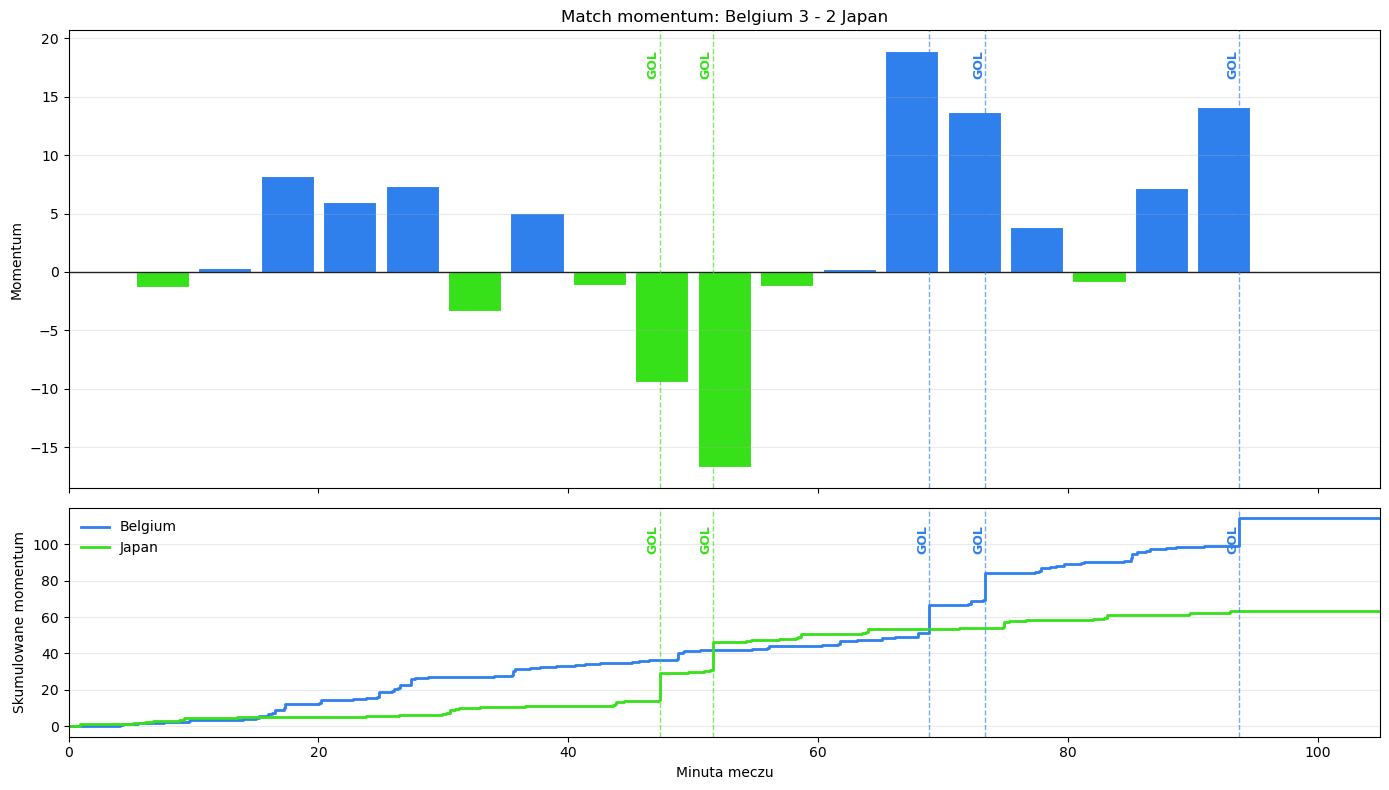

In [21]:
fig_momentum, match_momentum = plot_match_momentum(df, df_matches, match_id, window=5)
match_momentum.head(10)


## Gole wykryte w danych



In [22]:
momentum_table, teams, momentum_events = build_match_momentum(df, match_info, window=5)
goals = goal_events(momentum_events)
goals


,match_minute,team.name
0,47.316667,Japan
1,51.566667,Japan
2,68.883333,Belgium
3,73.383333,Belgium
4,93.733333,Belgium


## Skumulowane momentum jako tabela


In [23]:
cum_momentum = cumulative_momentum(momentum_events)
cum_momentum.tail(10)


,match_minute,team.name,momentum_score,cum_momentum
222,88.700000,Belgium,0.350000,98.484568
223,88.816667,Belgium,0.250000,98.734568
224,89.283333,Japan,0.150000,61.386967
225,89.683333,Japan,0.250000,61.636967
226,89.783333,Japan,0.350000,61.986967
227,90.933333,Belgium,0.150000,98.884568
228,91.750000,Japan,0.350000,62.336967
229,92.983333,Japan,1.036472,63.373439
230,93.650000,Belgium,0.350000,99.234568
231,93.733333,Belgium,15.000000,114.234568


## Skumulowane xG

Ten wykres jest osobno od momentum. Pokazuje czysto narastające xG ze strzałów.


team.name
Belgium    2.918
Japan      0.694
Name: cum_xg, dtype: float64

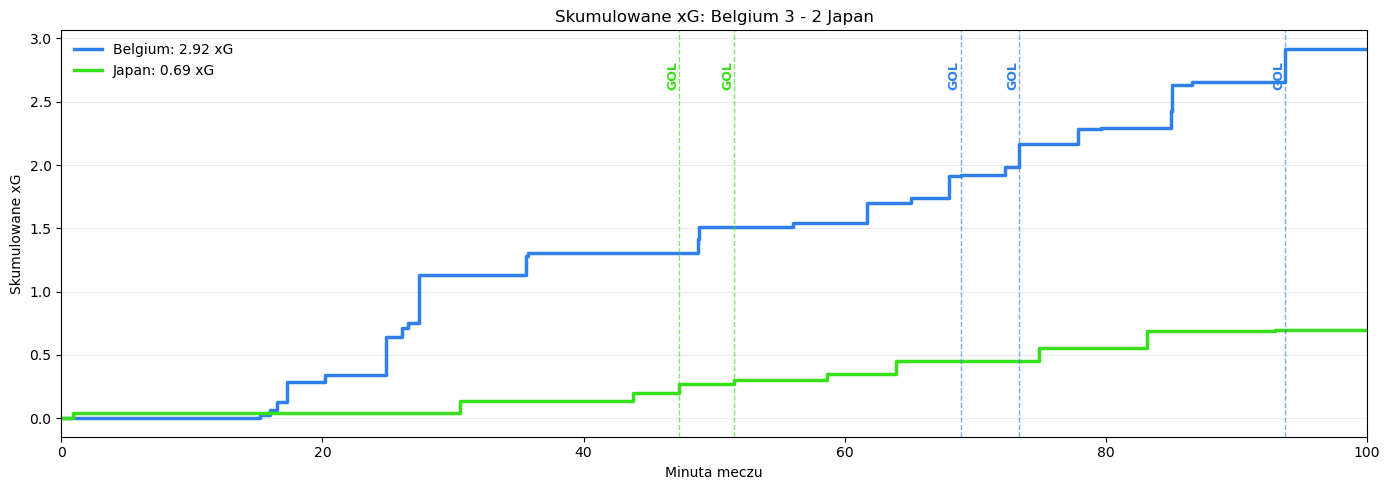

In [24]:
fig_xg = plot_cumulative_xg(df, df_matches, match_id, window=5)
xg_timeline = cumulative_xg(df)
xg_timeline.groupby("team.name")["cum_xg"].max().round(3)


## Wykresy dla wielu meczów


In [25]:
number_of_matches = 10

match_ids_to_plot = df_matches.head(number_of_matches)["match_id"].tolist()

#match_ids_to_plot = [8655, 8657, 8652	]

matches_overview = df_matches[df_matches["match_id"].isin(match_ids_to_plot)].copy()
matches_overview["home_team_name"] = matches_overview["home_team"].apply(lambda value: value.get("home_team_name") if isinstance(value, dict) else value)
matches_overview["away_team_name"] = matches_overview["away_team"].apply(lambda value: value.get("away_team_name") if isinstance(value, dict) else value)
matches_overview[["match_id", "match_date", "home_team_name", "away_team_name", "home_score", "away_score"]]


,match_id,match_date,home_team_name,away_team_name,home_score,away_score
0,8650,2018-07-06,Brazil,Belgium,1,2
1,7584,2018-07-02,Belgium,Japan,3,2
2,7554,2018-06-24,England,Panama,6,1
3,7539,2018-06-19,Poland,Senegal,1,2
4,7550,2018-06-22,Serbia,Switzerland,1,2
5,7538,2018-06-18,Sweden,South Korea,1,0
6,7534,2018-06-17,Germany,Mexico,0,1
7,7543,2018-06-20,Iran,Spain,0,1
8,7544,2018-06-20,Uruguay,Saudi Arabia,1,0
9,7546,2018-06-21,France,Peru,1,0


### match_id: `8650` | Brazil 1 - 2 Belgium

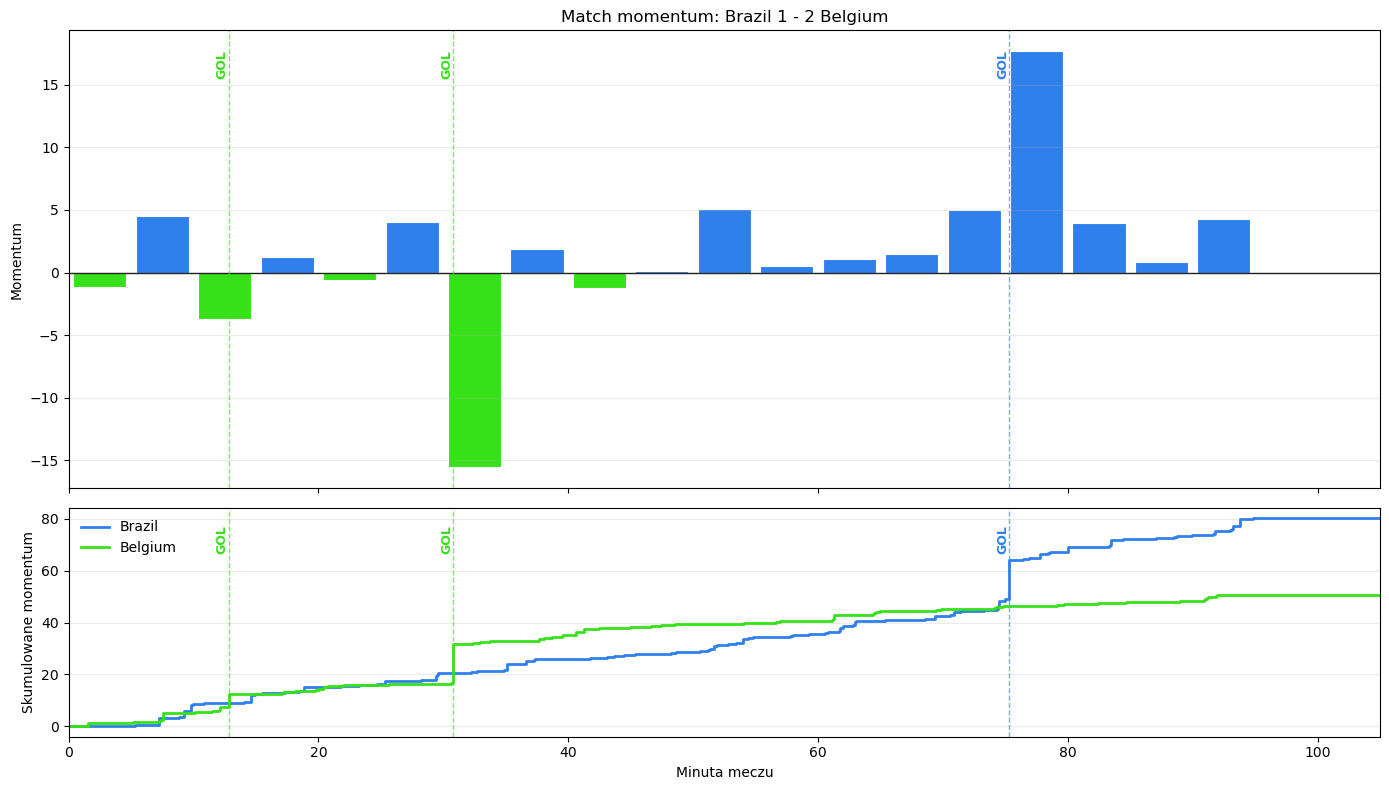

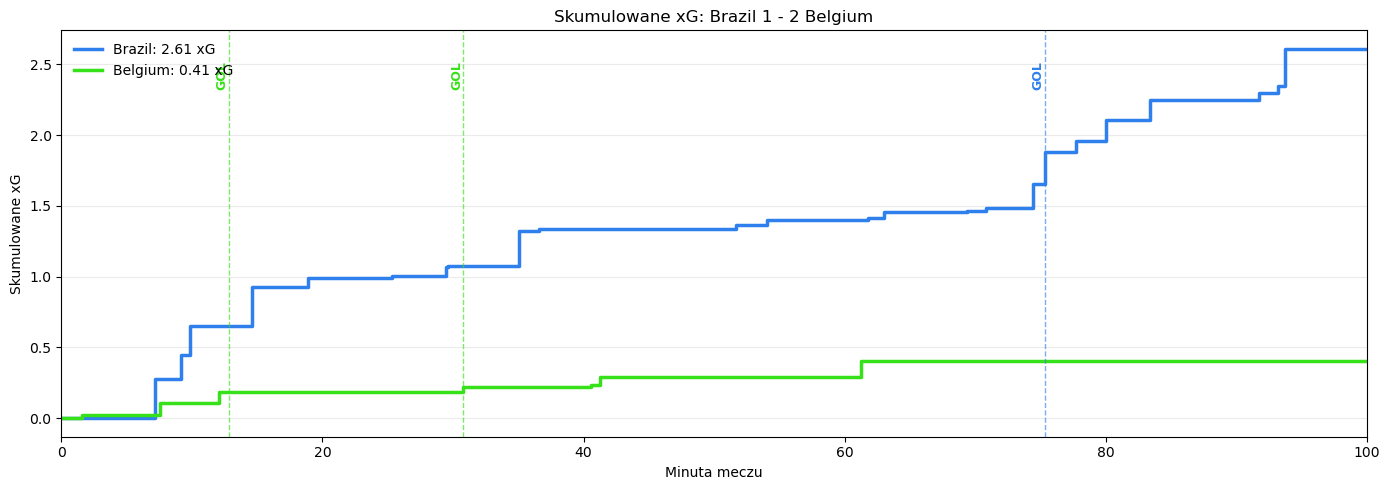

### match_id: `7584` | Belgium 3 - 2 Japan

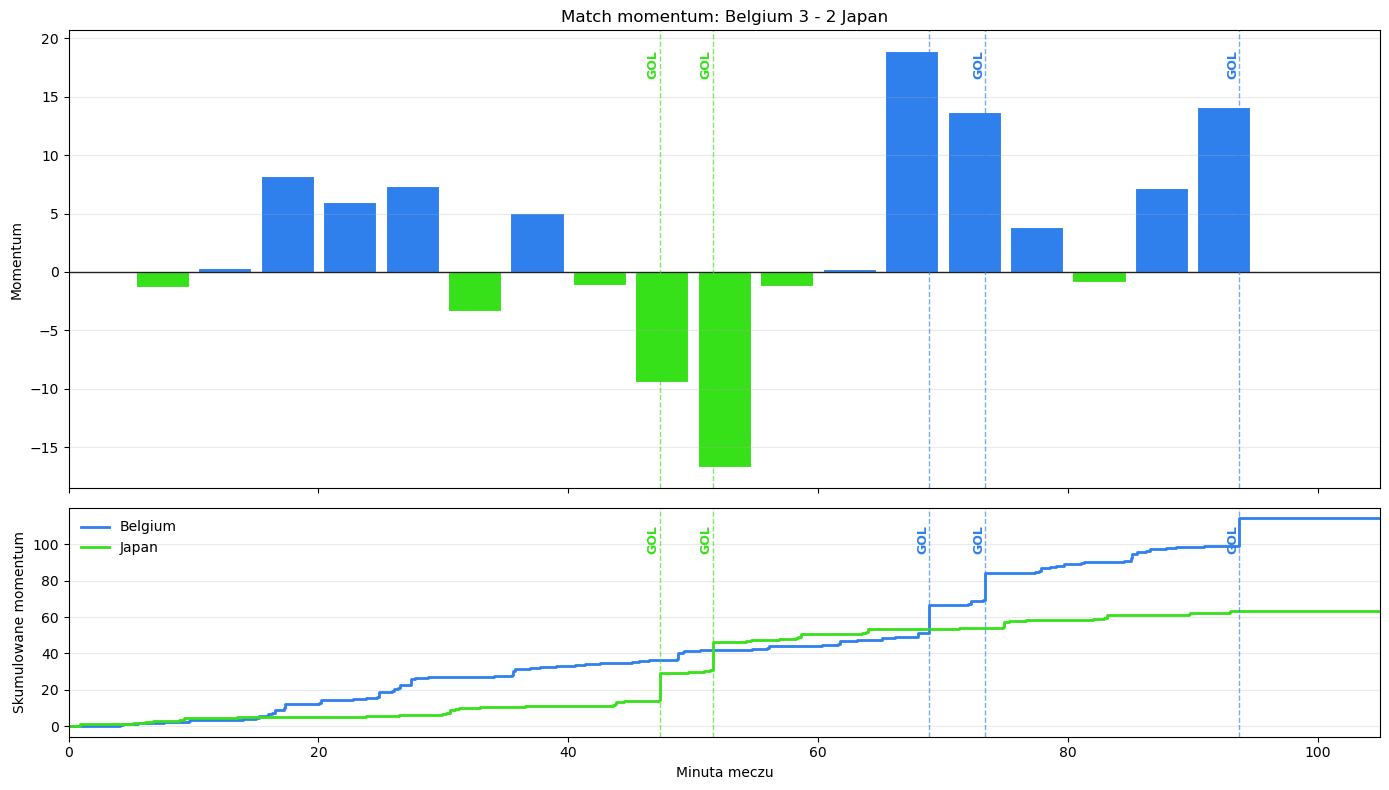

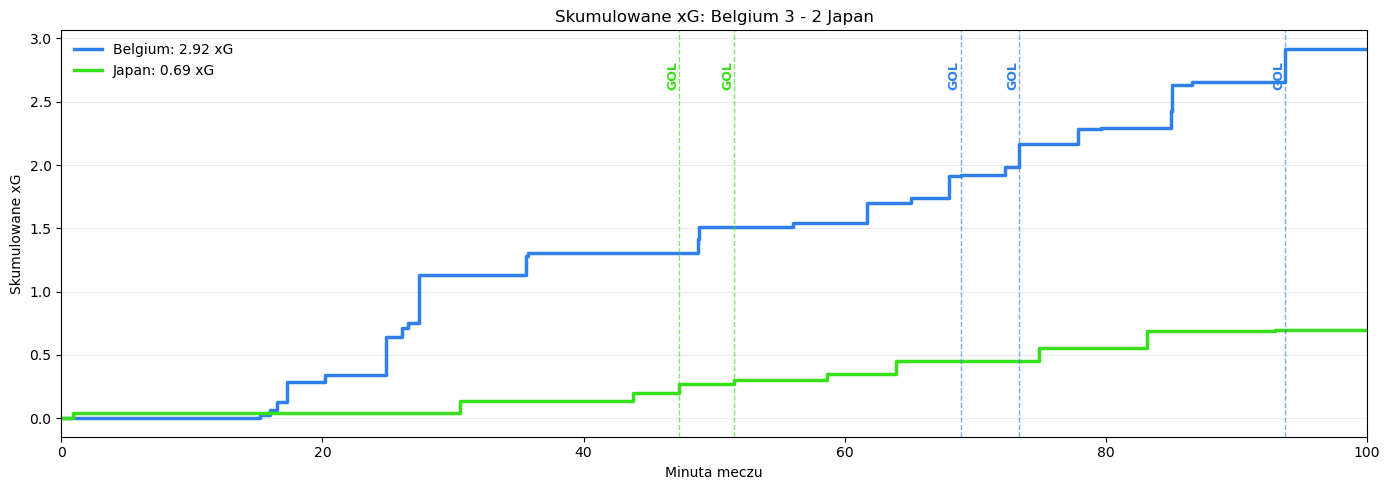

### match_id: `7554` | England 6 - 1 Panama

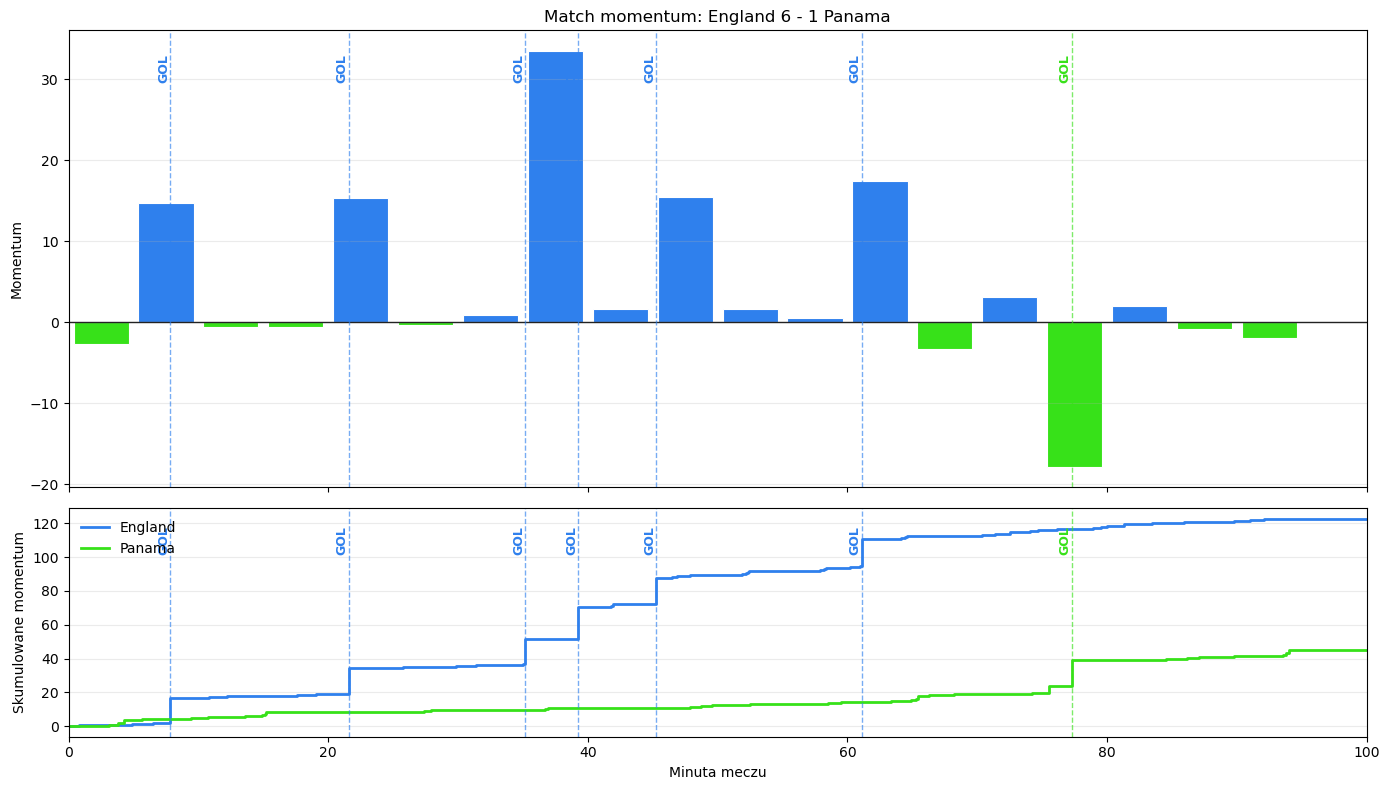

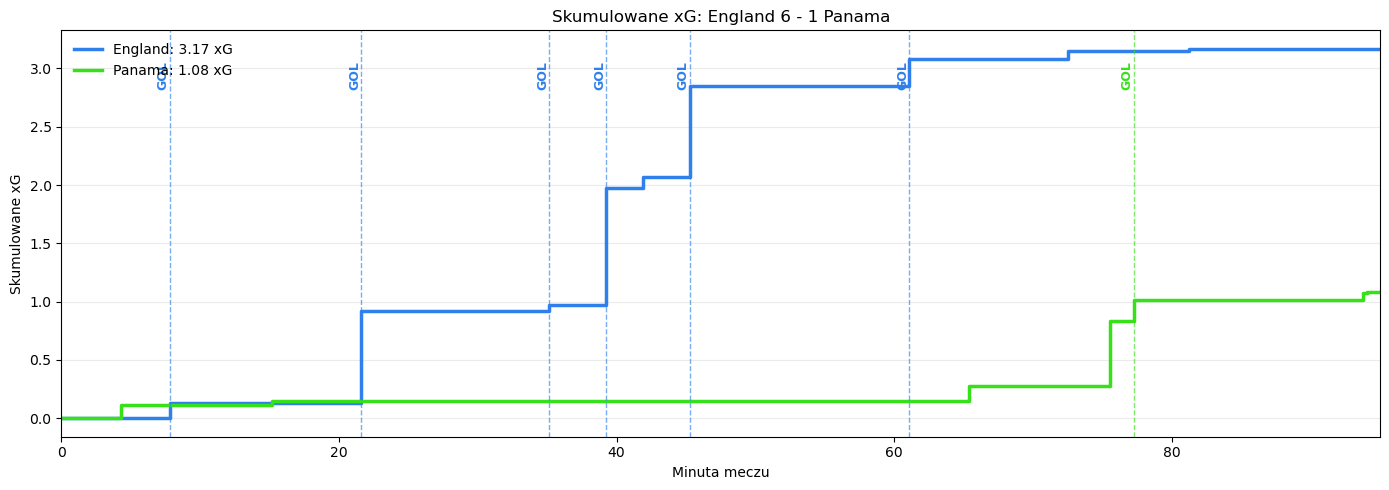

### match_id: `7539` | Poland 1 - 2 Senegal

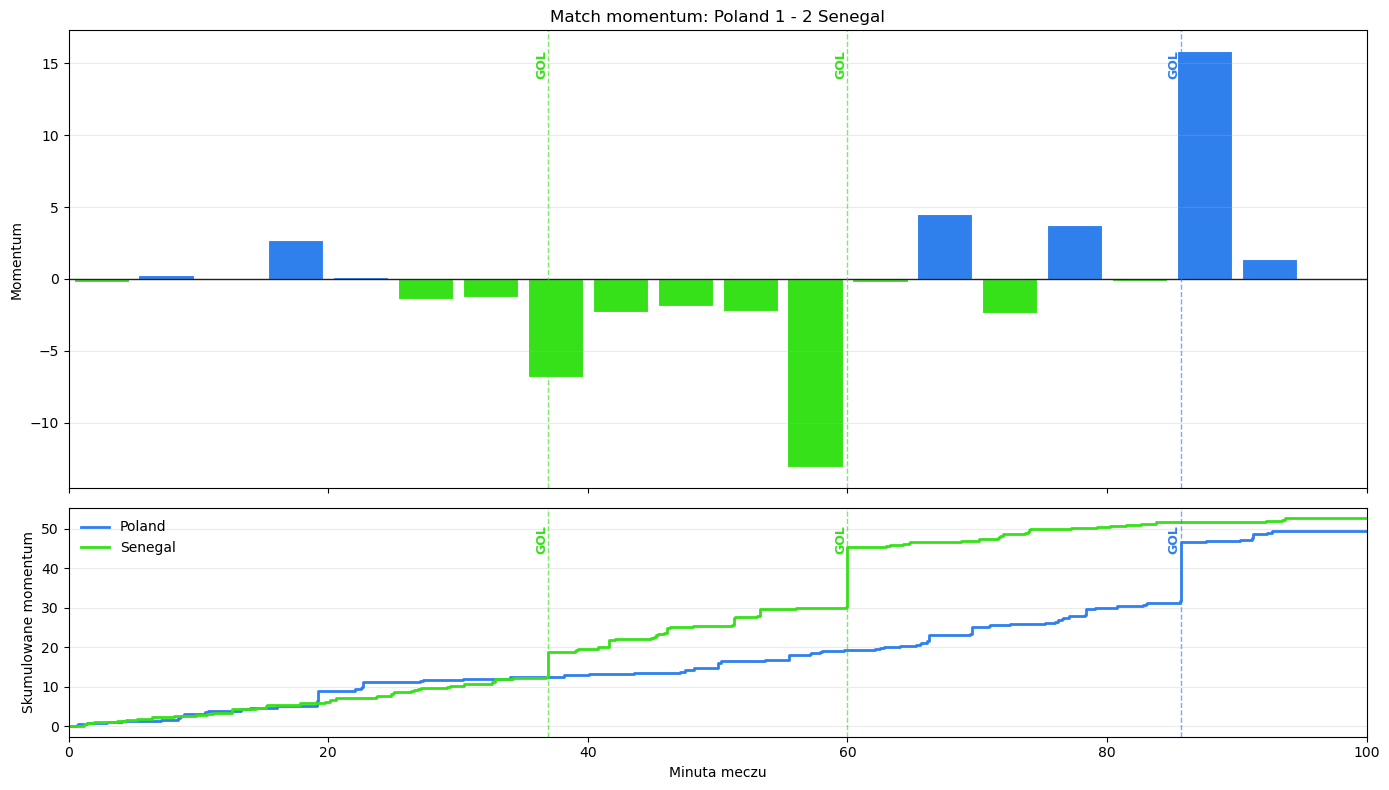

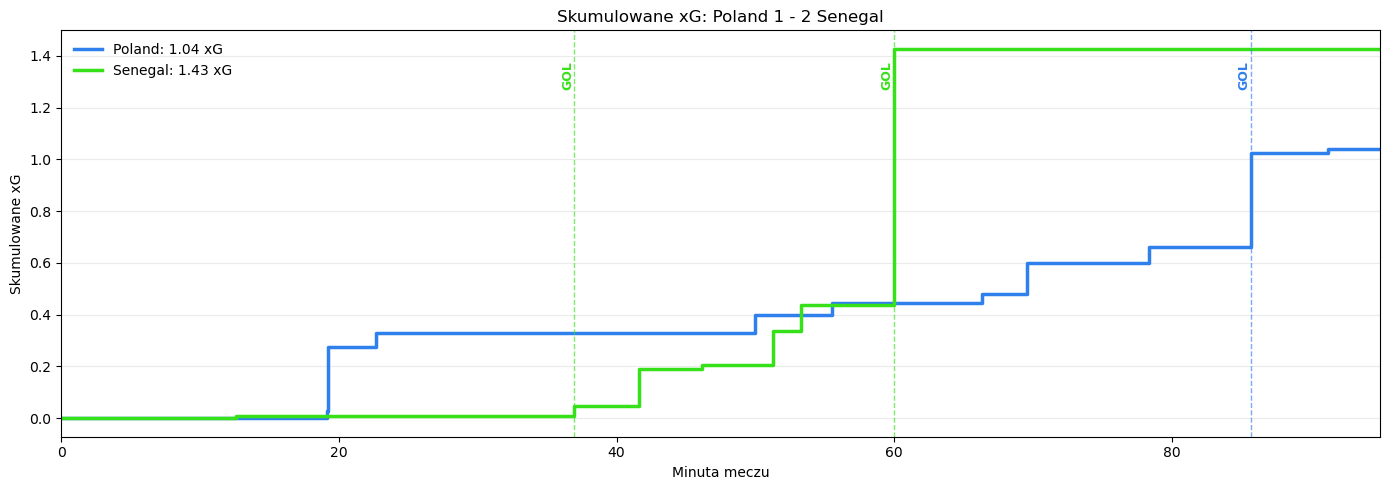

### match_id: `7550` | Serbia 1 - 2 Switzerland

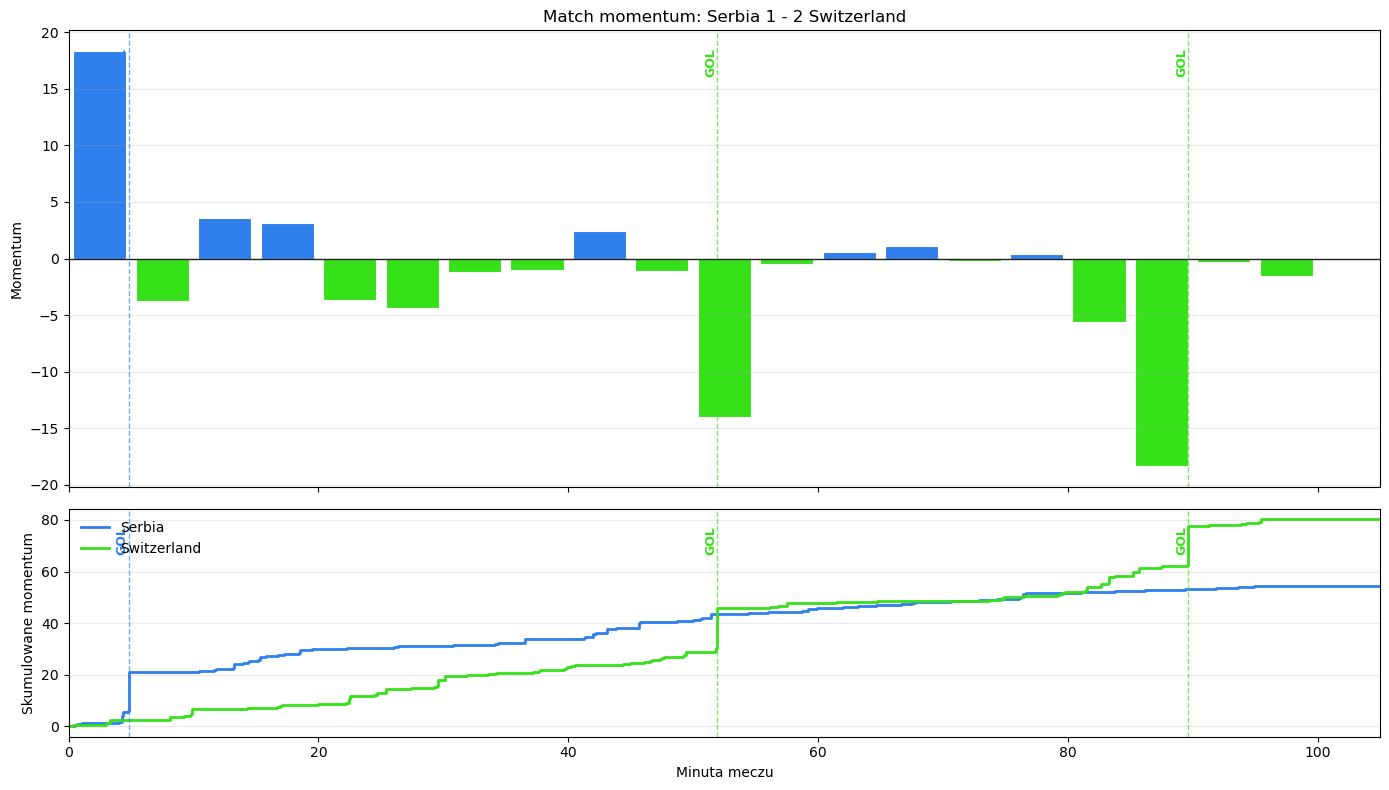

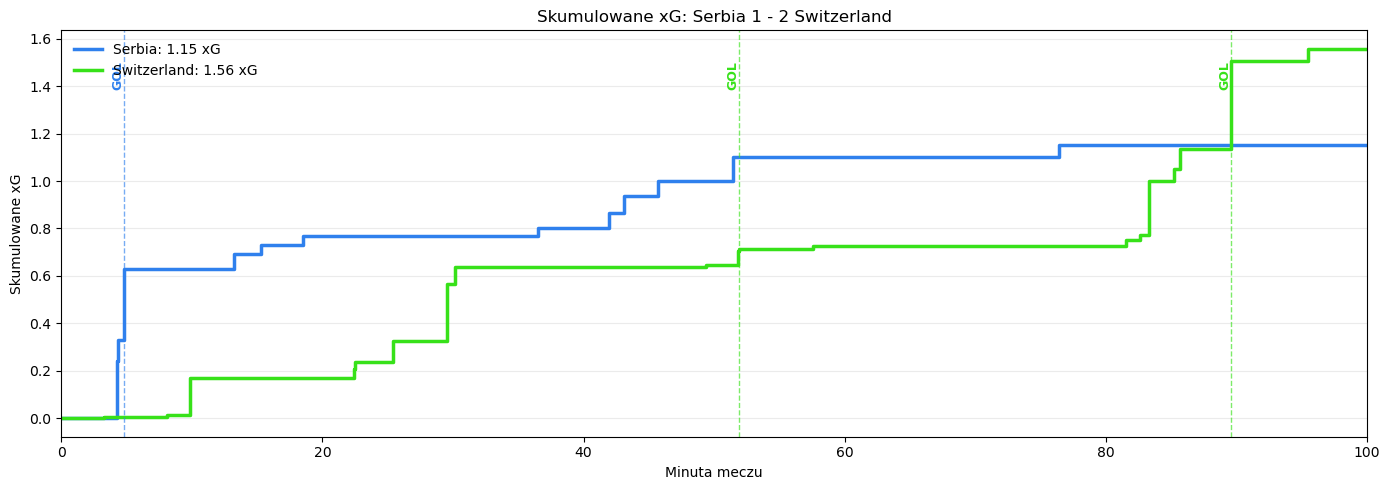

### match_id: `7538` | Sweden 1 - 0 South Korea

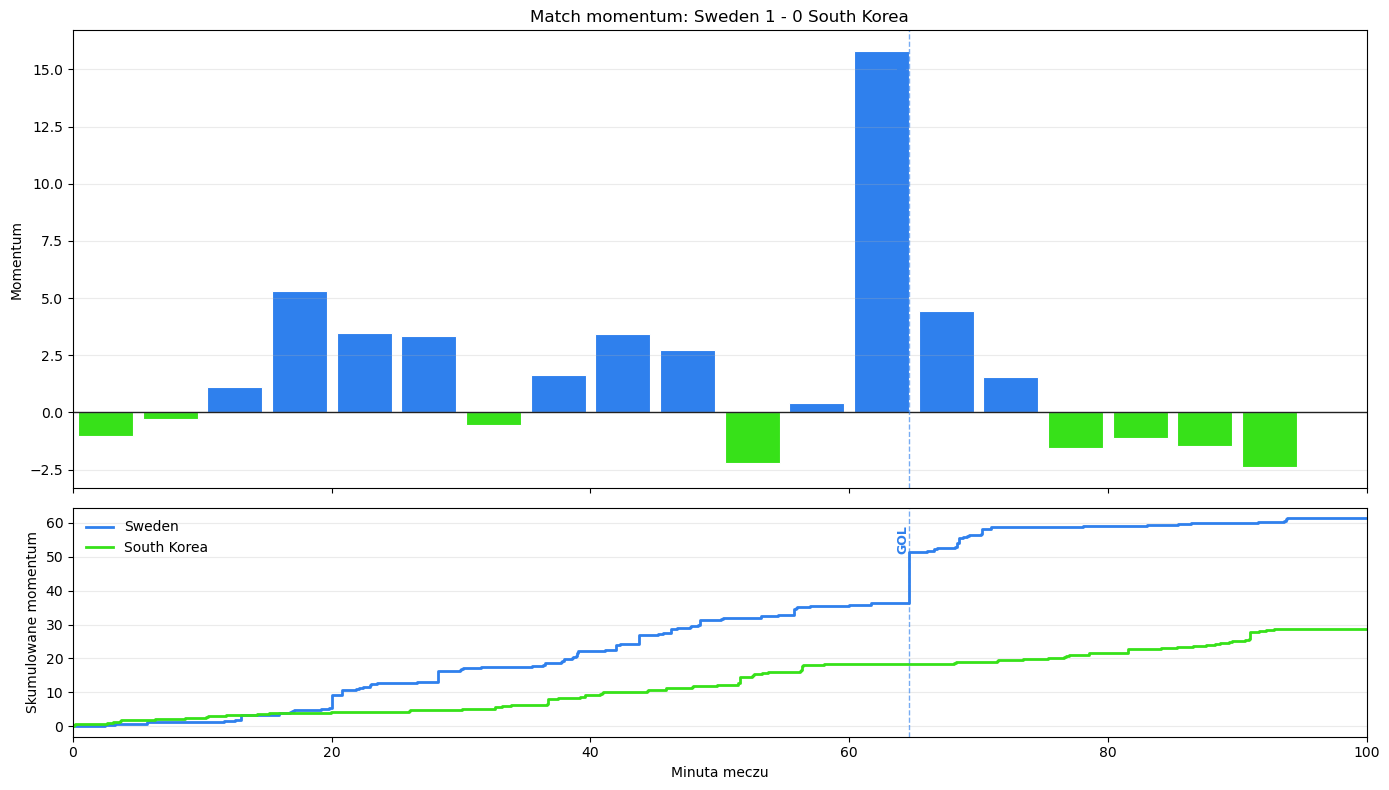

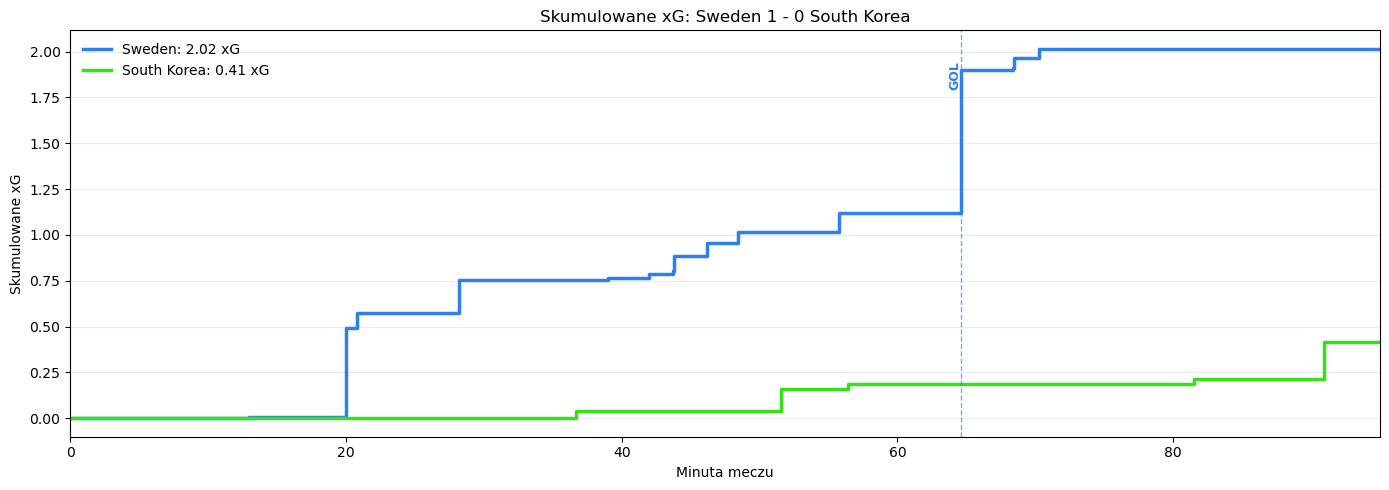

### match_id: `7534` | Germany 0 - 1 Mexico

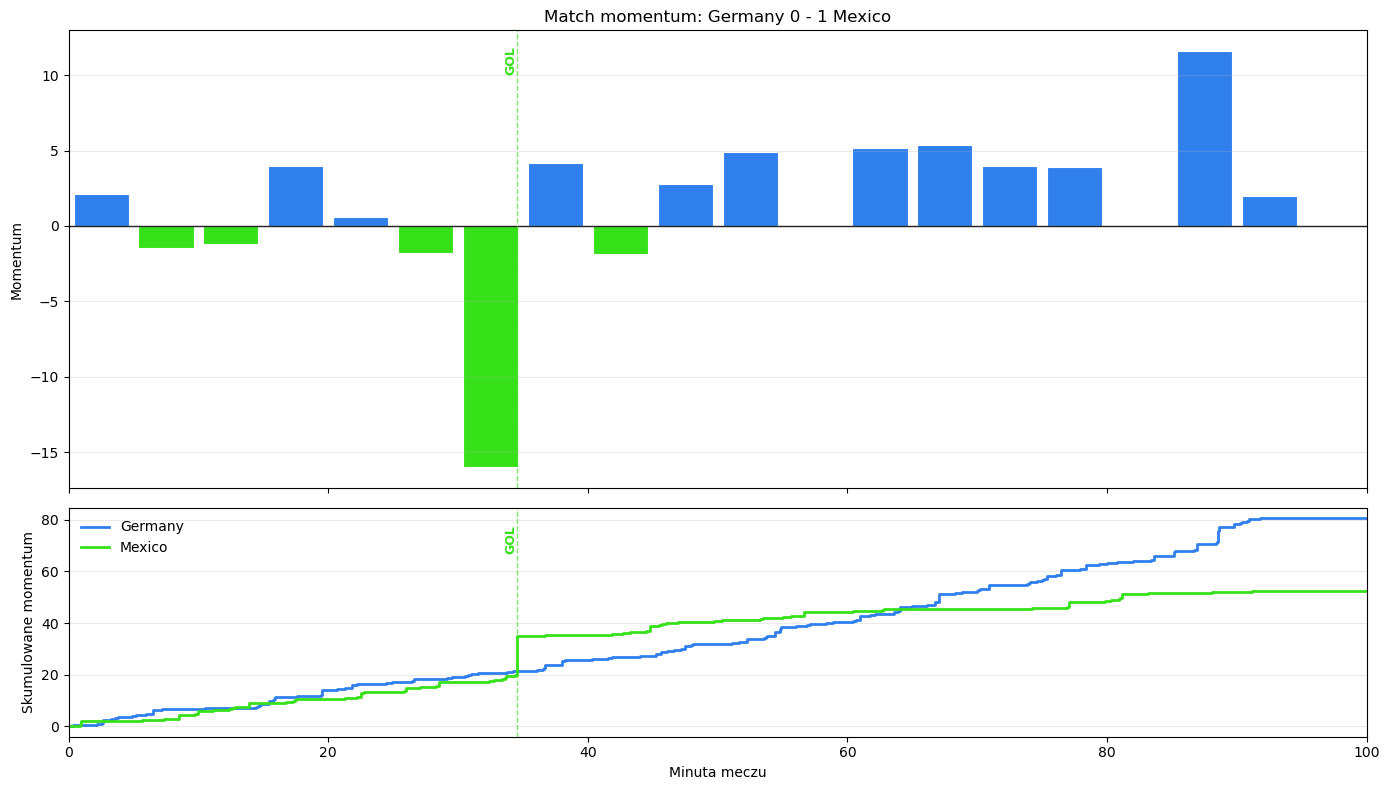

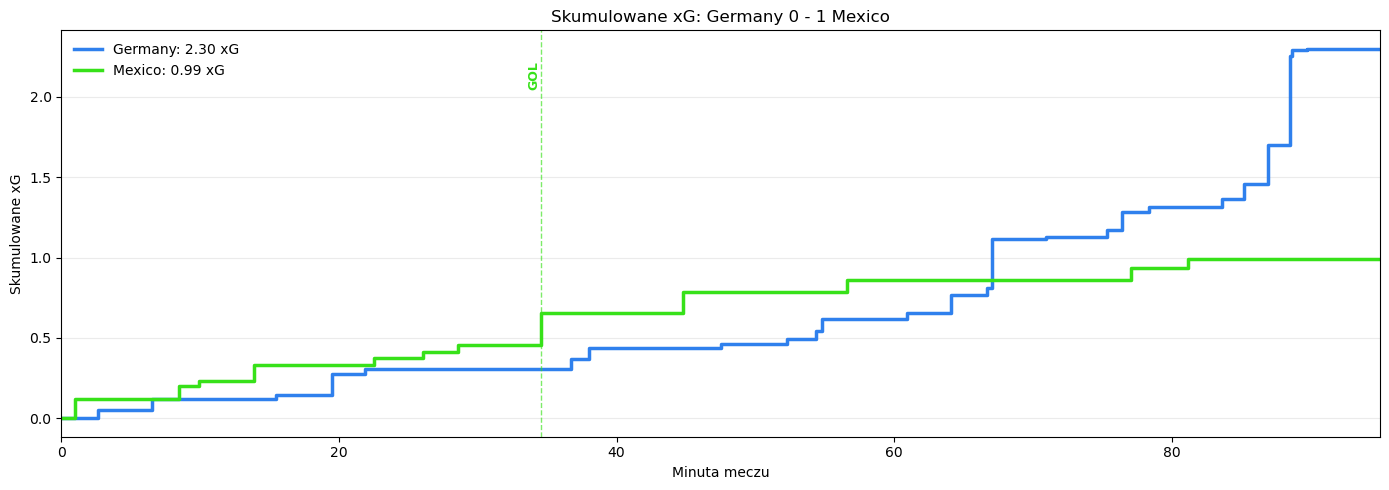

### match_id: `7543` | Iran 0 - 1 Spain

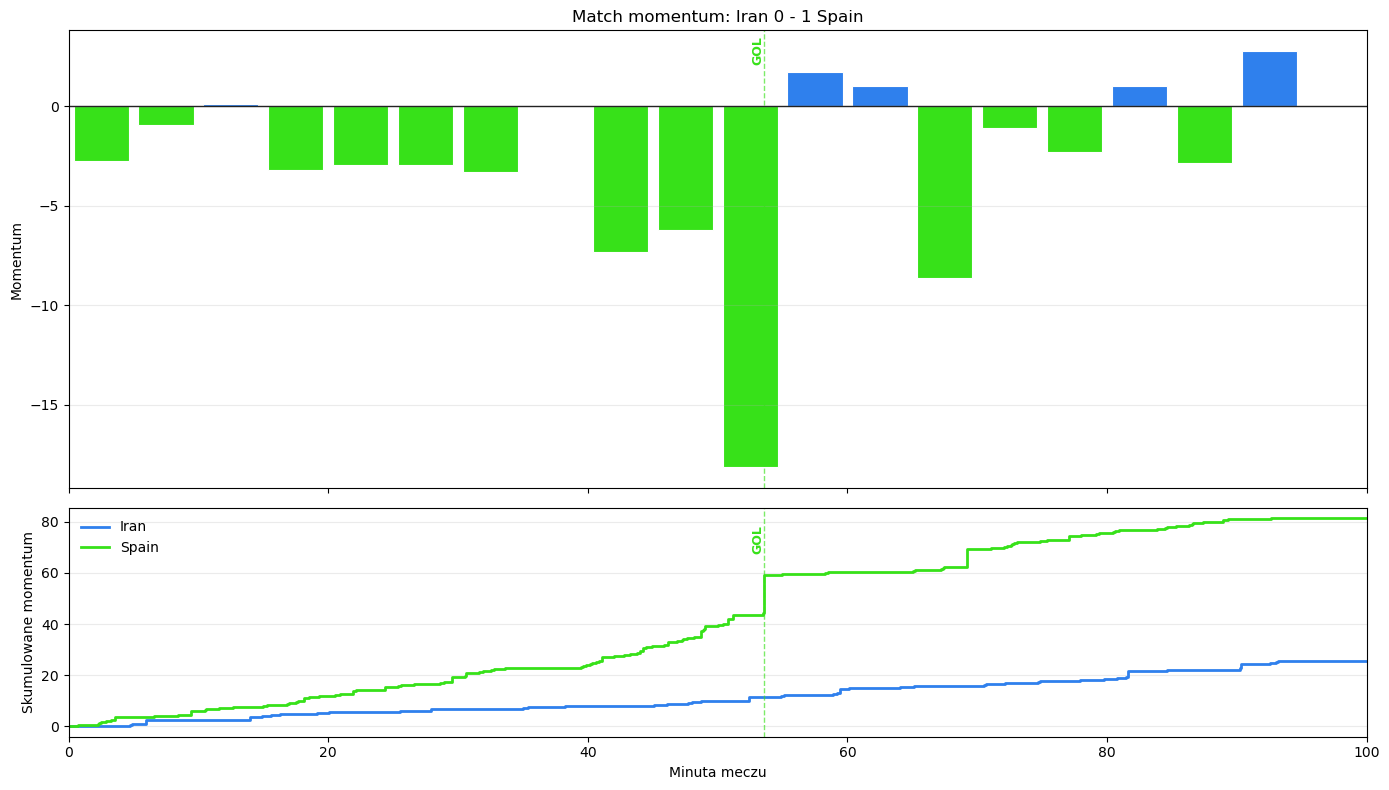

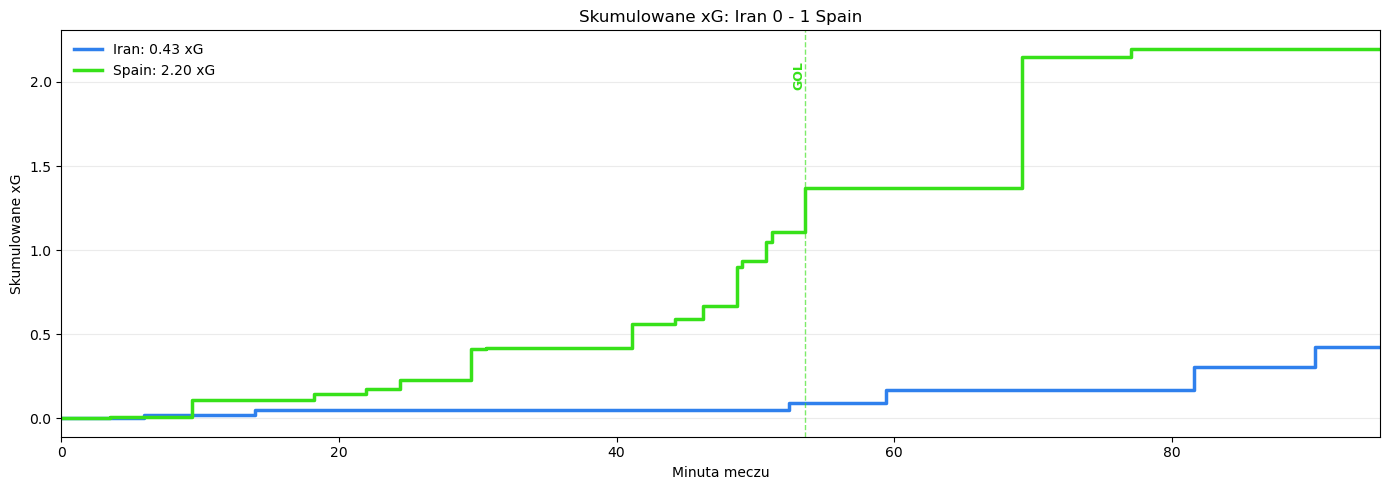

### match_id: `7544` | Uruguay 1 - 0 Saudi Arabia

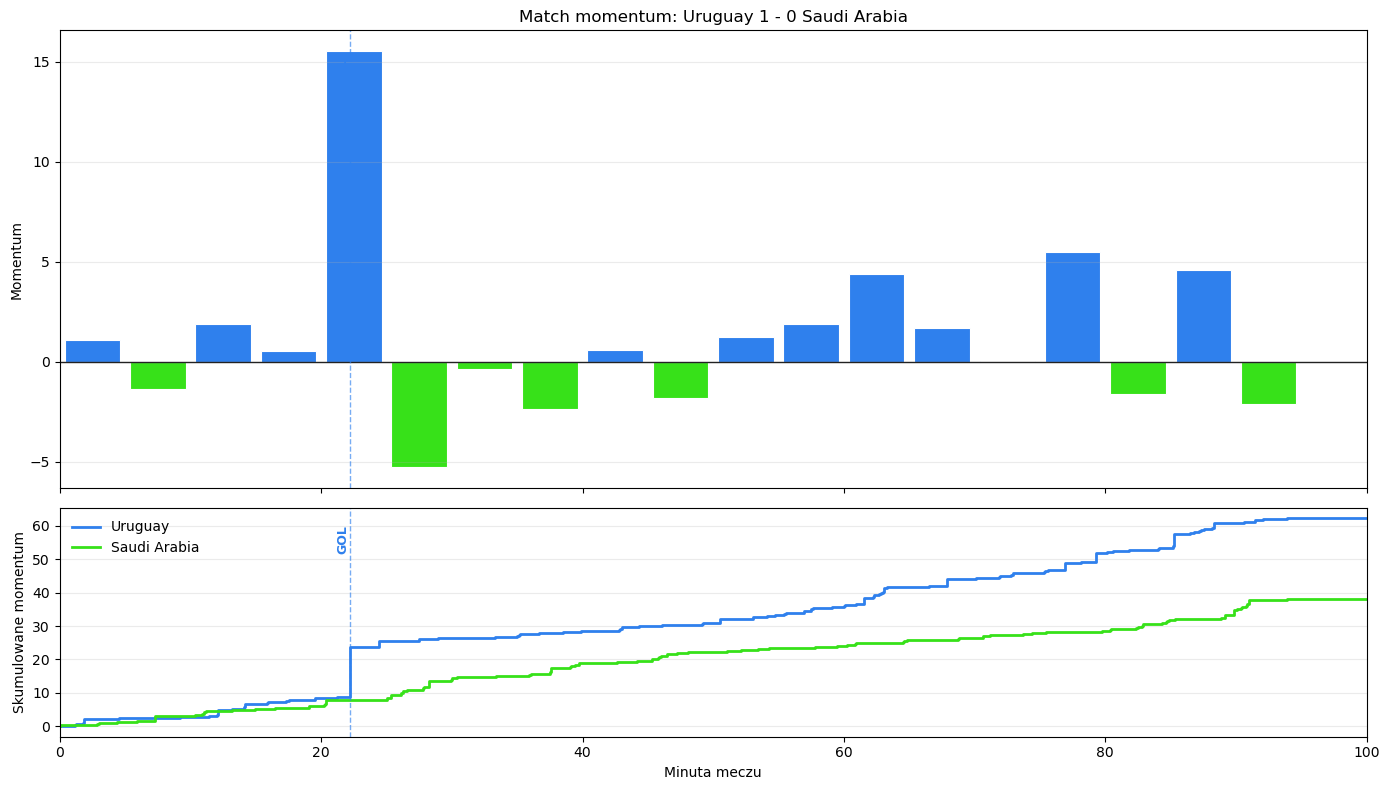

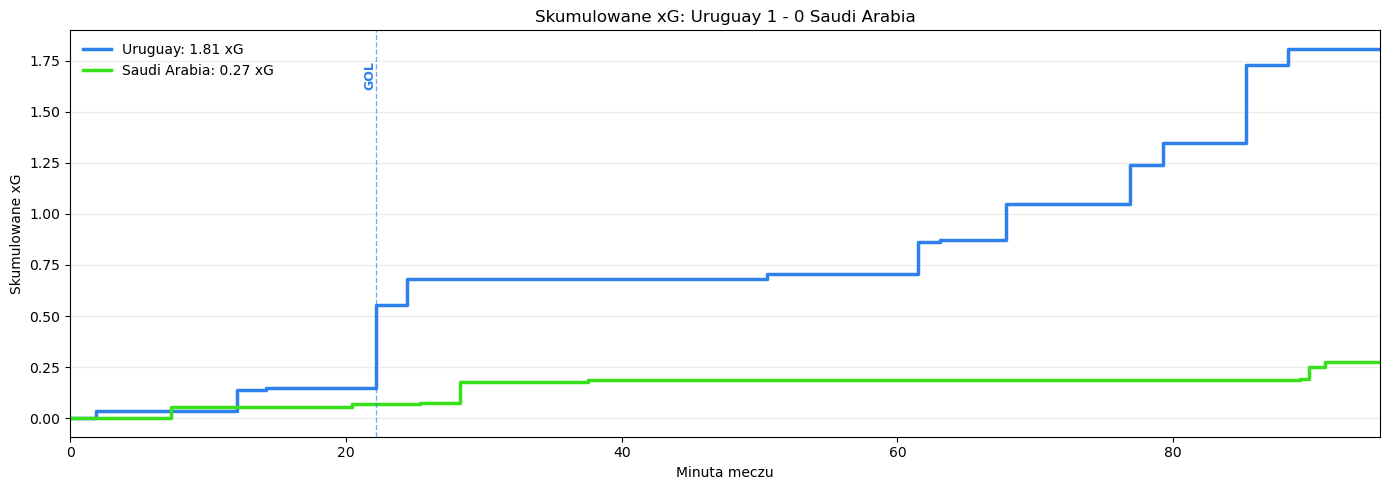

### match_id: `7546` | France 1 - 0 Peru

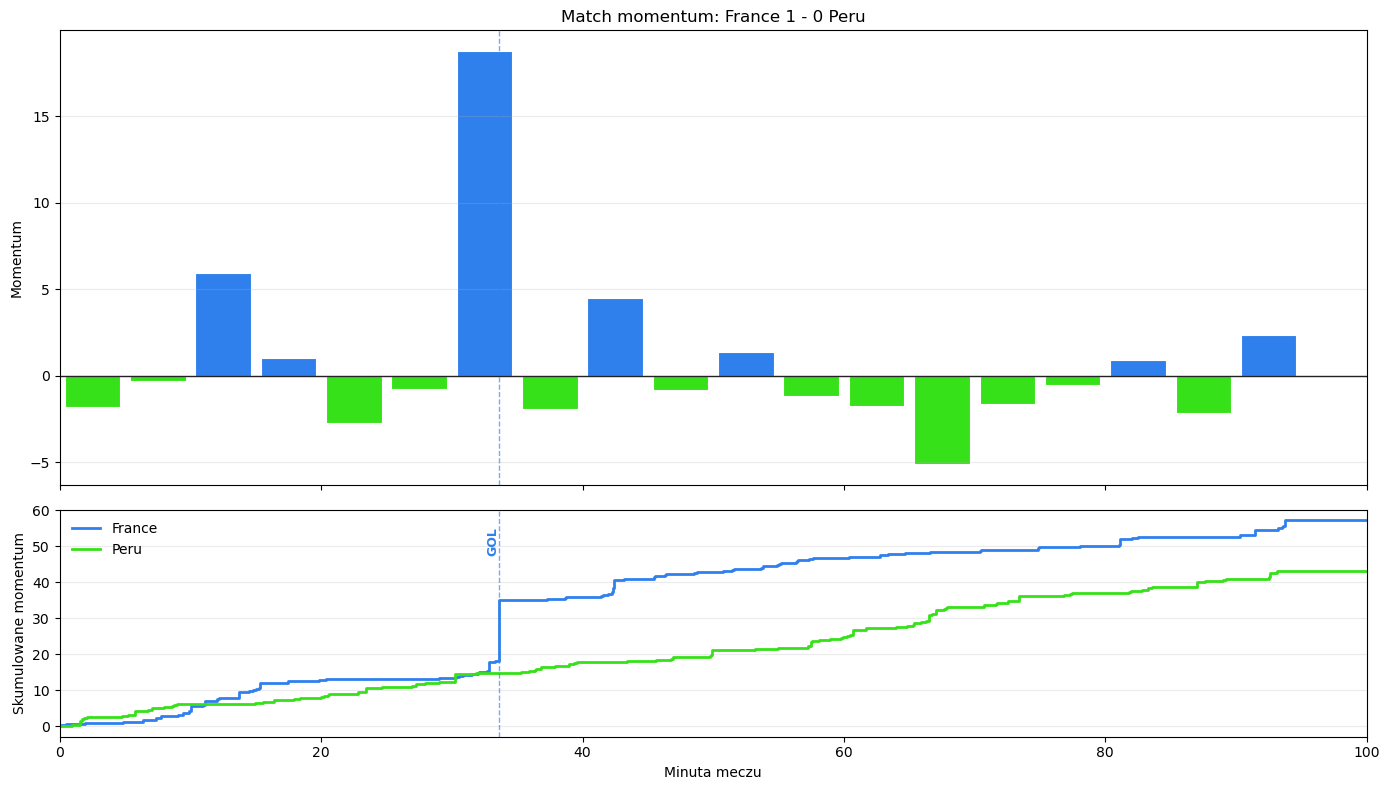

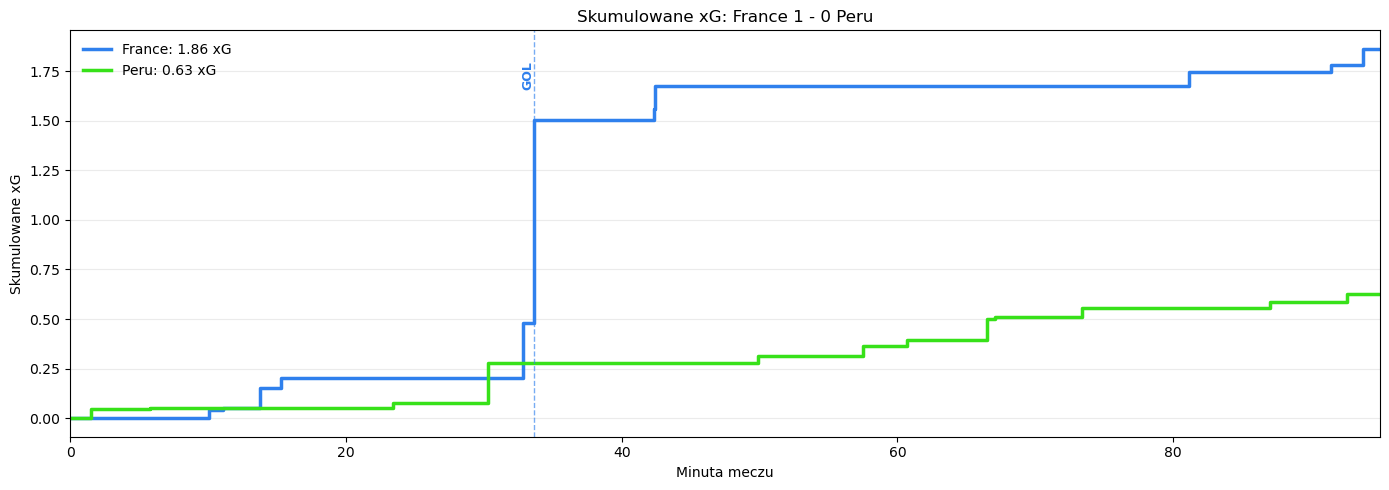

In [26]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

for selected_match_id in match_ids_to_plot:
    selected_match_info = df_matches.loc[df_matches["match_id"].eq(selected_match_id)].iloc[0]
    selected_home_team = team_name(selected_match_info, "home_team")
    selected_away_team = team_name(selected_match_info, "away_team")
    selected_events = load_events(selected_match_id)

    display(Markdown(
        f"### match_id: `{selected_match_id}` | "
        f"{selected_home_team} {selected_match_info['home_score']} - "
        f"{selected_match_info['away_score']} {selected_away_team}"
    ))

    fig_momentum, selected_momentum = plot_match_momentum(
        selected_events,
        df_matches,
        selected_match_id,
        window=5,
    )
    display(fig_momentum)

    fig_xg = plot_cumulative_xg(
        selected_events,
        df_matches,
        selected_match_id,
        window=5,
    )
    display(fig_xg)

    plt.close(fig_momentum)
    plt.close(fig_xg)
